# Comparisons with BGEP ULS sea ice draft estimates updated with new data

**Summary:** In this notebook, we produce comparisons of the gridded ICESat-2 sea ice thickness data with draft measurements obtained from Upward Looking Sonar moorings deployed in the Beaufort Sea. 

 
**Version history**: Version 1 (01/01/2022)
 

# Import notebook dependencies

In [46]:
import xarray as xr 
import pandas as pd
import numpy as np
import itertools
import pyproj 
from netCDF4 import Dataset
import scipy.interpolate 
from utils.read_data_utils import read_book_data, read_IS2SITMOGR4 # Helper function for reading the data from the bucket
from utils.plotting_utils import compute_gridcell_winter_means, interactiveArcticMaps, interactive_winter_mean_maps, interactive_winter_comparison_lineplot # Plotting
from scipy import stats
import datetime
# Plotting dependencies
import cartopy.crs as ccrs
from textwrap import wrap
import hvplot.pandas
import holoviews as hv
import matplotlib.pyplot as plt
from matplotlib.axes import Axes
from cartopy.mpl.geoaxes import GeoAxes
GeoAxes._pcolormesh_patched = Axes.pcolormesh # Helps avoid some weird issues with the polar projection 
%config InlineBackend.figure_format = 'retina'
import matplotlib as mpl

# Interpolating/smoothing packages 
from scipy.interpolate import griddata
from scipy.spatial import KDTree
from astropy.convolution import convolve
from astropy.convolution import Gaussian2DKernel

mpl.rcParams['figure.dpi'] = 200 # Sets figure size in the notebook

# Remove warnings to improve display
import warnings 
warnings.filterwarnings('ignore') 


In [47]:
grid_size=25
ib_agg_str='mean'
extra='new'

# Define the variables to compare
variables_ice = [
    'ice_thickness',
    'ice_thickness_sm', 
    'ice_thickness_mw99', 
    'ice_thickness_j22', 
    'cs2_sea_ice_thickness_UBRIS'
]

# Define the variables to compare
variables_snow = [
    'snow_depth', 
    'snow_depth_sm', 
    'snow_depth_mw99', 
]

variables_all = variables_ice+variables_snow

In [48]:
IS2SITMOGR4_v3 = read_IS2SITMOGR4(data_type='zarr-s3', persist=True) 
IS2SITMOGR4_v3


load zarr from S3 bucket
zarr_path: s3://icesat-2-sea-ice-us-west-2/IS2SITMOGR4_V3/IS2SITMOGR4_V3_201811-202404.zarr
<xarray.Dataset>
Dimensions:                         (time: 46, y: 448, x: 304)
Coordinates:
    latitude                        (y, x) float32 dask.array<chunksize=(224, 304), meta=np.ndarray>
    longitude                       (y, x) float32 dask.array<chunksize=(224, 304), meta=np.ndarray>
  * time                            (time) datetime64[ns] 2018-11-01 ... 2024...
  * x                               (x) float32 -3.838e+06 ... 3.738e+06
  * y                               (y) float32 5.838e+06 ... -5.338e+06
Data variables: (12/27)
    crs                             (time) int32 dask.array<chunksize=(46,), meta=np.ndarray>
    freeboard                       (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    freeboard_int                   (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_density        

<xarray.Dataset>
Dimensions:                         (time: 46, y: 448, x: 304)
Coordinates:
    latitude                        (y, x) float32 31.1 31.2 ... 34.58 34.47
    longitude                       (y, x) float32 168.3 168.1 ... -10.18 -9.999
  * time                            (time) datetime64[ns] 2018-11-01 ... 2024...
  * x                               (x) float32 -3.838e+06 ... 3.738e+06
  * y                               (y) float32 5.838e+06 ... -5.338e+06
Data variables: (12/27)
    crs                             (time) int32 dask.array<chunksize=(46,), meta=np.ndarray>
    freeboard                       (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    freeboard_int                   (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_density                     (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_density_j22                 (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_thickness                   (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ...                              ...
    snow_density_sm                 (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_density_w99                (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_depth                      (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_depth_int                  (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_depth_mw99                 (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_depth_sm                   (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
Attributes:
    contact:      Alek Petty (akpetty@umd.edu)
    description:  Aggregated IS2SITMOGR4 V3 dataset.
    history:      Created 28/11/23
    reference:    Official NSIDC data doi: 10.5067/CV6JEXEE31HF. Derived data...

In [49]:
import glob
from datetime import datetime
def add_time_dim_v3(xda):
    """ dummy function to just set current time as a new dimension to concat files over, change later! """
    xda = xda.set_coords(["latitude","longitude", "y", "x"])
    xda = xda.expand_dims(time = [datetime.now()])
    return xda

def read_IS2SITMOGR4_SUMMER(version='V0', local_data_path="./data/IS2SITMOGR4_SUMMER/"): 
    """ Read in IS2SITMOGR4 summer monthly gridded thickness dataset from local netcdf files

    """
    
    print(local_data_path+version+'/*.nc')
    filenames = glob.glob(local_data_path+version+'/*.nc')
    if len(filenames) == 0: 
        raise ValueError("No files, exit")
        return None
    
    dates = [pd.to_datetime(file.split("IS2SIT_SUMMER_01_")[1].split("_")[0], format = "%Y%m")  for file in filenames]
    # Add a dummy time then add the dates I want, seemed the easiest solution
    is2_ds = xr.open_mfdataset(filenames, preprocess = add_time_dim_v3, engine='netcdf4')
            
    is2_ds["time"] = dates

    # Sort by time as glob file list wasn't!
    is2_ds = is2_ds.sortby("time")
    is2_ds = is2_ds.set_coords(["latitude","longitude","y","x"])
    
    is2_ds = is2_ds.assign_coords(longitude=(["y","x"], is2_ds.longitude.values))
    is2_ds = is2_ds.assign_coords(latitude=(["y","x"], is2_ds.latitude.values))
    
    is2_ds = is2_ds.assign_attrs(description="Aggregated IS2SITMOGR4 summer "+version+" dataset.")

    return is2_ds
IS2SITMOGR4_summer_v0 = read_IS2SITMOGR4_SUMMER()
IS2SITMOGR4_summer_v0


./data/IS2SITMOGR4_SUMMER/V0/*.nc


<xarray.Dataset>
Dimensions:                         (time: 11, y: 448, x: 304)
Coordinates:
  * time                            (time) datetime64[ns] 2019-05-01 ... 2021...
    longitude                       (y, x) float32 168.3 168.1 ... -10.18 -9.999
    latitude                        (y, x) float32 31.1 31.2 ... 34.58 34.47
  * x                               (x) float32 -3.838e+06 ... 3.738e+06
  * y                               (y) float32 5.838e+06 ... -5.338e+06
Data variables: (12/26)
    crs                             (time) int32 -2147483647 ... -2147483647
    ice_thickness_sm                (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_thickness_unc               (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    num_segments                    (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    mean_day_of_month               (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_depth_sm                   (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ...                              ...
    ice_thickness_unc_freeboard     (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_thickness_unc_ice_density   (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_thickness_unc_snow_density  (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_thickness_unc_snow_depth    (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    sea_ice_conc                    (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    region_mask                     (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
Attributes:
    contact:      Alek Petty (akpetty@umd.edu)
    description:  Aggregated IS2SITMOGR4 summer V0 dataset.
    history:      Created 20/12/23

In [50]:
IS2SITMOGR4_v3 = IS2SITMOGR4_summer_v0.merge(IS2SITMOGR4_v3)
IS2SITMOGR4_v3

<xarray.Dataset>
Dimensions:                         (time: 57, x: 304, y: 448)
Coordinates:
  * time                            (time) datetime64[ns] 2018-11-01 ... 2024...
  * x                               (x) float32 -3.838e+06 ... 3.738e+06
  * y                               (y) float32 5.838e+06 ... -5.338e+06
    longitude                       (y, x) float32 168.3 168.1 ... -10.18 -9.999
    latitude                        (y, x) float32 31.1 31.2 ... 34.58 34.47
Data variables: (12/36)
    crs                             (time) float64 dask.array<chunksize=(57,), meta=np.ndarray>
    ice_thickness_sm                (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_thickness_unc               (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    num_segments                    (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    mean_day_of_month               (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_depth_sm                   (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ...                              ...
    ice_type                        (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_density                    (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_density_w99                (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_depth                      (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_depth_int                  (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_depth_mw99                 (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
Attributes:
    contact:      Alek Petty (akpetty@umd.edu)
    description:  Aggregated IS2SITMOGR4 summer V0 dataset.
    history:      Created 20/12/23

In [51]:
out_proj = 'EPSG:3411'
out_lons = IS2SITMOGR4_v3.longitude.values
out_lats = IS2SITMOGR4_v3.latitude.values

mapProj = pyproj.Proj("+init=" + out_proj)
xptsIS2, yptsIS2 = mapProj(out_lons, out_lats)

In [52]:
def getCS2ubris(mapProj, dataPathCS2, dataset):
    """ Read in the University of Bristol CryoSat-2 sea ice thickness data

    
    Args:
        dataPathCS2 (str): location of data
        
    Returns
        xptsT (2d numpy array): x coordinates on our map projection
        yptsT (2d numpy array): y coordinates on our map projection
        thicknessCS (2d numpy array): monthly sea ice thickness estimates
        

    """
    ubris_f = xr.open_dataset(dataPathCS2+dataset, decode_times=False)

    # Issue with time starting from year 0!
    # Re-set it to start from some other year
    ubris_f = ubris_f.rename({'Time':'time'})
    ubris_f['time'] = ubris_f['time']-679352
    ubris_f.time.attrs["units"] = "days since 1860-01-01"
    decoded_time = xr.decode_cf(ubris_f)

    ubris_f['time']=decoded_time.time
    ubris_f = ubris_f.swap_dims({'t': 'time'})

    # Resample to monthly, note that the S just makes the index start on the 1st of the month
    thicknessCS = ubris_f.resample(time="MS").mean()
    xptsT, yptsT = mapProj(thicknessCS.isel(time=0).Longitude, thicknessCS.isel(time=0).Latitude)
    
    return xptsT, yptsT, thicknessCS

def regridToICESat2(dataArrayNEW, xptsNEW, yptsNEW, xptsIS2, yptsIS2):  
    """ Regrid new data to ICESat-2 grid 
    
    Args: 
        dataArrayNEW (xarray DataArray): Numpy variable array to be gridded to ICESat-2 grid 
        xptsNEW (numpy array): x-values of dataArrayNEW projected to ICESat-2 map projection 
        yptsNEW (numpy array): y-values of dataArrayNEW projected to ICESat-2 map projection 
        xptsIS2 (numpy array): ICESat-2 longitude projected to ICESat-2 map projection
        yptsIS2 (numpy array): ICESat-2 latitude projected to ICESat-2 map projection
    
    Returns: 
        gridded (numpy array): data regridded to ICESat-2 map projection
    
    """
    #gridded = []
    #for i in range(len(dataArrayNEW.values)): 
    gridded = scipy.interpolate.griddata((xptsNEW.flatten(),yptsNEW.flatten()), dataArrayNEW.flatten(), (xptsIS2, yptsIS2), method = 'nearest')
    try:
        gridded = scipy.interpolate.griddata((xptsNEW.flatten(),yptsNEW.flatten()), dataArrayNEW.flatten(), (xptsIS2, yptsIS2), method = 'nearest')
    except:
        try:
            gridded = scipy.interpolate.griddata((xptsNEW,yptsNEW), dataArrayNEW, (xptsIS2, yptsIS2), method = 'nearest')
        except:
            print('Error interpolating..')
    
    return gridded

def regrid_ubris_is2(mapProj, xptsIS2, yptsIS2, out_lons, out_lats, date_range, dataPathCS2='/home/jovyan/Data/CS2/UIT/', dataset='ubristol_cryosat2_seaicethickness_nh_80km_v1p7.nc'):

    cs2_ubris = []
    valid_dates=[]

    xptsT_ubris, yptsT_ubris, cs2_ubris_raw = getCS2ubris(mapProj, dataPathCS2, dataset)
    
    for date in date_range:
        
            
        try:
            cs2_ubris_temp_is2grid = regridToICESat2(cs2_ubris_raw.Sea_Ice_Thickness.sel(time=date).values, xptsT_ubris, yptsT_ubris, xptsIS2, yptsIS2) 
            ice_conc_is2grid = regridToICESat2(cs2_ubris_raw.Sea_Ice_Concentration.sel(time=date).values, xptsT_ubris, yptsT_ubris, xptsIS2, yptsIS2)     
            #cs2_ubris_temp_is2grid[ice_conc_is2grid<0.5]=np.nan
            
            cs2_ice_type_is2grid = regridToICESat2(cs2_ubris_raw.Sea_Ice_Type.sel(time=date).values, xptsT_ubris, yptsT_ubris, xptsIS2, yptsIS2) 

            
        except:
            print(date)
            print('no CS-2 data or issue with gridding, so skipping...')
            continue
        valid_dates.append(date)

        #cs2_ubris_temp_is2grid_xr = xr.DataArray(data = cs2_ubris_temp_is2grid, 
        #                        dims = ['y', 'x'], 
        #                        coords = {'latitude': (('y','x'), out_lats), 'longitude': (('y','x'), out_lons), 'x': (('x'), IS2SITMOGR4_v3.x.values),  'y': (('y'), IS2SITMOGR4_v3.y.values)}, 
        #                        name = 'cs2_sea_ice_thickness_UBRIS')

        cs2_ubris_temp_is2grid_xr = xr.Dataset({'cs2_sea_ice_thickness_UBRIS': (('y', 'x'), cs2_ubris_temp_is2grid), 
                                'cs2_sea_ice_type_UBRIS': (('y', 'x'), cs2_ice_type_is2grid)}, 
                                coords = {'latitude': (('y','x'), out_lats), 'longitude': (('y','x'), out_lons), 'x': (('x'), IS2SITMOGR4_v3.x.values),  'y': (('y'), IS2SITMOGR4_v3.y.values)} 
                                )
        
        cs2_ubris.append(cs2_ubris_temp_is2grid_xr)

    cs2_ubris = xr.concat(cs2_ubris, 'time')
    #cs2_ubris = cs2_ubris.assign_coords(time=valid_dates)
    cs2_ubris_attrs = {'units': 'meters', 'long_name': 'University of Bristol CryoSat-2 Arctic sea ice thickness', 'data_download': 'https://data.bas.ac.uk/full-record.php?id=GB/NERC/BAS/PDC/01613', 
            'download_date': '09-2022', 'citation': 'Landy, J.C., Dawson, G.J., Tsamados, M. et al. A year-round satellite sea-ice thickness record from CryoSat-2. Nature 609, 517–522 (2022). https://doi.org/10.1038/s41586-022-05058-5'} 
    cs2_ubris = cs2_ubris.assign_coords(time=valid_dates)
    cs2_ubris = cs2_ubris.assign_attrs(cs2_ubris_attrs)  

    return cs2_ubris




start_date_cs2 = "Nov 2018"
end_date_cs2 = "July 2021"
# MS indicates a time frequency of start of the month
date_range_cs2 = pd.date_range(start=start_date_cs2, end=end_date_cs2, freq='MS') 

cs2_ubris = regrid_ubris_is2(mapProj, xptsIS2, yptsIS2, out_lons, out_lats, date_range_cs2,
                             dataPathCS2='/Users/akpetty/Data/CS2/', dataset='uit_cryosat2_seaicethickness_nh_80km_v1p7.nc')

IS2SITMOGR4_v3 = IS2SITMOGR4_v3.merge(cs2_ubris)

In [53]:
IS2SITMOGR4_v3 = IS2SITMOGR4_v3.sel(time=slice('2019-10-01', '2020-09-30'))

In [54]:
IS2SITMOGR4_v3_int = IS2SITMOGR4_v3.copy(deep=True)

In [55]:
# ... existing code ...

# Interpolation settings 
method = "linear" 

# Create a new dataset to store the interpolated values
#IS2SITMOGR4_v3_int = xr.Dataset()

# Loop over each time step
for time_index in range(IS2SITMOGR4_v3.dims['time']):
    print(time_index)# Loop over each variable
    for var in variables_all:
        print(var)# Perform linear interpolation for the current time step
        try:
            is2_to_interp = IS2SITMOGR4_v3[var].isel(time=time_index).values.copy()
            is2_to_interp[np.where(IS2SITMOGR4_v3.sea_ice_conc.isel(time=time_index) < 0.15)] = 0  # Set 15% conc or less to 0 thickness
            np_interpolated = griddata((xptsIS2[(np.isfinite(is2_to_interp))], 
                                        yptsIS2[(np.isfinite(is2_to_interp))]), 
                                        is2_to_interp[(np.isfinite(is2_to_interp))].flatten(),
                                        (xptsIS2, yptsIS2), 
                                        fill_value=np.nan,
                                        method=method)
            np_interpolated[~(np.isfinite(IS2SITMOGR4_v3.sea_ice_conc.isel(time=time_index)))] = np.nan  # Remove thickness data where cdr data is nan 
            np_interpolated[np.where(IS2SITMOGR4_v3.sea_ice_conc.isel(time=time_index) < 0.5)] = np.nan  # Remove thickness data where cdr data < 50% concentration

            x_stddev = 0.5
            kernel = Gaussian2DKernel(x_stddev=x_stddev)
            np_interpolated_gauss = convolve(np_interpolated, kernel)
            np_interpolated_gauss[~(np.isfinite(IS2SITMOGR4_v3.sea_ice_conc.isel(time=time_index)))] = np.nan  # Remove thickness data where cdr data is nan 
            np_interpolated_gauss[np.where(IS2SITMOGR4_v3.sea_ice_conc.isel(time=time_index) < 0.5)] = np.nan  # Remove thickness data where cdr data < 50% concentration
            print(np_interpolated_gauss.shape)
            # Ensure the data is in the correct shape
            #np_interpolated_gauss = np_interpolated_gauss[np.newaxis, :, :]  # Add a new axis for time

            # Add the interpolated data to the new dataset
            IS2SITMOGR4_v3[var].isel(time=time_index)[:] = np_interpolated_gauss
        except:
            print(var)
            print(time_index)
            print('no data or issue with gridding, so skipping...')
            #IS2SITMOGR4_v3[var].isel(time=time_index)[:] = np.full(np_interpolated_gauss.shape, np.nan)
            continue
        #else:
        #    IS2SITMOGR4_v3_int[var] = xr.concat([IS2SITMOGR4_v3_int[var], xr.DataArray(np_interpolated_gauss, dims=('time', 'y', 'x'))], dim='time')

# Add latitude, longitude, and time coordinates to the new dataset
#IS2SITMOGR4_v3_int = IS2SITMOGR4_v3_int.assign_coords({
#    'latitude': (('y', 'x'), IS2SITMOGR4_v3.latitude.values),
#    'longitude': (('y', 'x'), IS2SITMOGR4_v3.longitude.values),
#    'time': IS2SITMOGR4_v3.time.values
#})

# ... existing code ...

0
ice_thickness
(448, 304)
ice_thickness_sm
(448, 304)
ice_thickness_mw99
(448, 304)
ice_thickness_j22
(448, 304)
cs2_sea_ice_thickness_UBRIS
(448, 304)
snow_depth
(448, 304)
snow_depth_sm
(448, 304)
snow_depth_mw99
(448, 304)
1
ice_thickness
(448, 304)
ice_thickness_sm
(448, 304)
ice_thickness_mw99
(448, 304)
ice_thickness_j22
(448, 304)
cs2_sea_ice_thickness_UBRIS
(448, 304)
snow_depth
(448, 304)
snow_depth_sm
(448, 304)
snow_depth_mw99
(448, 304)
2
ice_thickness
(448, 304)
ice_thickness_sm
(448, 304)
ice_thickness_mw99
(448, 304)
ice_thickness_j22
(448, 304)
cs2_sea_ice_thickness_UBRIS
(448, 304)
snow_depth
(448, 304)
snow_depth_sm
(448, 304)
snow_depth_mw99
(448, 304)
3
ice_thickness
(448, 304)
ice_thickness_sm
(448, 304)
ice_thickness_mw99
(448, 304)
ice_thickness_j22
(448, 304)
cs2_sea_ice_thickness_UBRIS
(448, 304)
snow_depth
(448, 304)
snow_depth_sm
(448, 304)
snow_depth_mw99
(448, 304)
4
ice_thickness
(448, 304)
ice_thickness_sm
(448, 304)
ice_thickness_mw99
(448, 304)
ice_thi

In [56]:
IS2SITMOGR4_v3_int

<xarray.Dataset>
Dimensions:                         (time: 12, x: 304, y: 448)
Coordinates:
  * time                            (time) datetime64[ns] 2019-10-01 ... 2020...
  * x                               (x) float32 -3.838e+06 ... 3.738e+06
  * y                               (y) float32 5.838e+06 ... -5.338e+06
    longitude                       (y, x) float32 168.3 168.1 ... -10.18 -9.999
    latitude                        (y, x) float32 31.1 31.2 ... 34.58 34.47
Data variables: (12/38)
    crs                             (time) float64 dask.array<chunksize=(12,), meta=np.ndarray>
    ice_thickness_sm                (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_thickness_unc               (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    num_segments                    (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    mean_day_of_month               (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_depth_sm                   (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ...                              ...
    snow_density_w99                (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_depth                      (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_depth_int                  (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_depth_mw99                 (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    cs2_sea_ice_thickness_UBRIS     (time, y, x) float64 0.0 0.0 0.0 ... 0.0 0.0
    cs2_sea_ice_type_UBRIS          (time, y, x) float64 nan nan nan ... nan nan
Attributes:
    contact:      Alek Petty (akpetty@umd.edu)
    description:  Aggregated IS2SITMOGR4 summer V0 dataset.
    history:      Created 20/12/23

In [57]:
IS2SITMOGR4_v3 = IS2SITMOGR4_v3_int
IS2SITMOGR4_v3

<xarray.Dataset>
Dimensions:                         (time: 12, x: 304, y: 448)
Coordinates:
  * time                            (time) datetime64[ns] 2019-10-01 ... 2020...
  * x                               (x) float32 -3.838e+06 ... 3.738e+06
  * y                               (y) float32 5.838e+06 ... -5.338e+06
    longitude                       (y, x) float32 168.3 168.1 ... -10.18 -9.999
    latitude                        (y, x) float32 31.1 31.2 ... 34.58 34.47
Data variables: (12/38)
    crs                             (time) float64 dask.array<chunksize=(12,), meta=np.ndarray>
    ice_thickness_sm                (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_thickness_unc               (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    num_segments                    (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    mean_day_of_month               (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_depth_sm                   (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ...                              ...
    snow_density_w99                (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_depth                      (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_depth_int                  (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_depth_mw99                 (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    cs2_sea_ice_thickness_UBRIS     (time, y, x) float64 0.0 0.0 0.0 ... 0.0 0.0
    cs2_sea_ice_type_UBRIS          (time, y, x) float64 nan nan nan ... nan nan
Attributes:
    contact:      Alek Petty (akpetty@umd.edu)
    description:  Aggregated IS2SITMOGR4 summer V0 dataset.
    history:      Created 20/12/23

In [58]:
# COARSEN TO MATCH 100 KM RESOLUTION OF IB
if grid_size==100:
    IS2SITMOGR4_v3 = IS2SITMOGR4_v3.coarsen(y=4, x=4, boundary='trim').mean()
    IS2SITMOGR4_v3

In [59]:
# Open the NetCDF file
# Replace 'path/to/your/file.nc' with the actual path to your NetCDF filemagnaprobe_data_IS2_collocated_all_ice_25km
#file_path = '/Users/akpetty/Data/IS2-obs-comparison-data/magnaprobe_on_is2_grid_'+str(grid_size)+'km_snow_depth_sit_PRELIMINARY.nc'
file_path = '/Users/akpetty/Data/IS2-obs-comparison-data/magnaprobe_data_IS2_collocated_all_ice_'+str(grid_size)+'km.nc'
dataset = xr.open_dataset(file_path)
dataset = dataset.rename({'date': 'time'})
dataset = dataset.transpose('y', 'x', 'time')
# Display the dataset
print(dataset)

<xarray.Dataset>
Dimensions:                   (y: 448, x: 304, time: 64)
Coordinates:
    lon                       (y, x) float32 ...
    lat                       (y, x) float32 ...
  * time                      (time) datetime64[ns] 2019-10-24 ... 2020-09-19
    crs                       int64 ...
  * x                         (x) float32 -3.838e+06 -3.812e+06 ... 3.738e+06
  * y                         (y) float32 5.838e+06 5.812e+06 ... -5.338e+06
Data variables:
    snow_thickness_mean       (y, x, time) float32 ...
    snow_thickness_median     (y, x, time) float32 ...
    snow_thickness_count      (y, x, time) float32 ...
    sea_ice_thickness_mean    (y, x, time) float32 ...
    sea_ice_thickness_median  (y, x, time) float32 ...
    sea_ice_thickness_count   (y, x, time) float32 ...


In [60]:
dataset_months = dataset.resample(time='MS').mean()
dataset_months


<xarray.Dataset>
Dimensions:                   (y: 448, x: 304, time: 12)
Coordinates:
    lon                       (y, x) float32 168.3 168.1 168.0 ... -10.18 -9.999
    lat                       (y, x) float32 31.1 31.2 31.3 ... 34.58 34.47
    crs                       int64 0
  * x                         (x) float32 -3.838e+06 -3.812e+06 ... 3.738e+06
  * y                         (y) float32 5.838e+06 5.812e+06 ... -5.338e+06
  * time                      (time) datetime64[ns] 2019-10-01 ... 2020-09-01
Data variables:
    snow_thickness_mean       (time, y, x) float32 nan nan nan ... nan nan nan
    snow_thickness_median     (time, y, x) float32 nan nan nan ... nan nan nan
    snow_thickness_count      (time, y, x) float32 nan nan nan ... nan nan nan
    sea_ice_thickness_mean    (time, y, x) float32 nan nan nan ... nan nan nan
    sea_ice_thickness_median  (time, y, x) float32 nan nan nan ... nan nan nan
    sea_ice_thickness_count   (time, y, x) float32 nan nan nan ... nan nan nan

In [61]:
IS2SITMOGR4_v3

<xarray.Dataset>
Dimensions:                         (time: 12, x: 304, y: 448)
Coordinates:
  * time                            (time) datetime64[ns] 2019-10-01 ... 2020...
  * x                               (x) float32 -3.838e+06 ... 3.738e+06
  * y                               (y) float32 5.838e+06 ... -5.338e+06
    longitude                       (y, x) float32 168.3 168.1 ... -10.18 -9.999
    latitude                        (y, x) float32 31.1 31.2 ... 34.58 34.47
Data variables: (12/38)
    crs                             (time) float64 dask.array<chunksize=(12,), meta=np.ndarray>
    ice_thickness_sm                (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_thickness_unc               (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    num_segments                    (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    mean_day_of_month               (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_depth_sm                   (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ...                              ...
    snow_density_w99                (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_depth                      (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_depth_int                  (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_depth_mw99                 (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    cs2_sea_ice_thickness_UBRIS     (time, y, x) float64 0.0 0.0 0.0 ... 0.0 0.0
    cs2_sea_ice_type_UBRIS          (time, y, x) float64 nan nan nan ... nan nan
Attributes:
    contact:      Alek Petty (akpetty@umd.edu)
    description:  Aggregated IS2SITMOGR4 summer V0 dataset.
    history:      Created 20/12/23

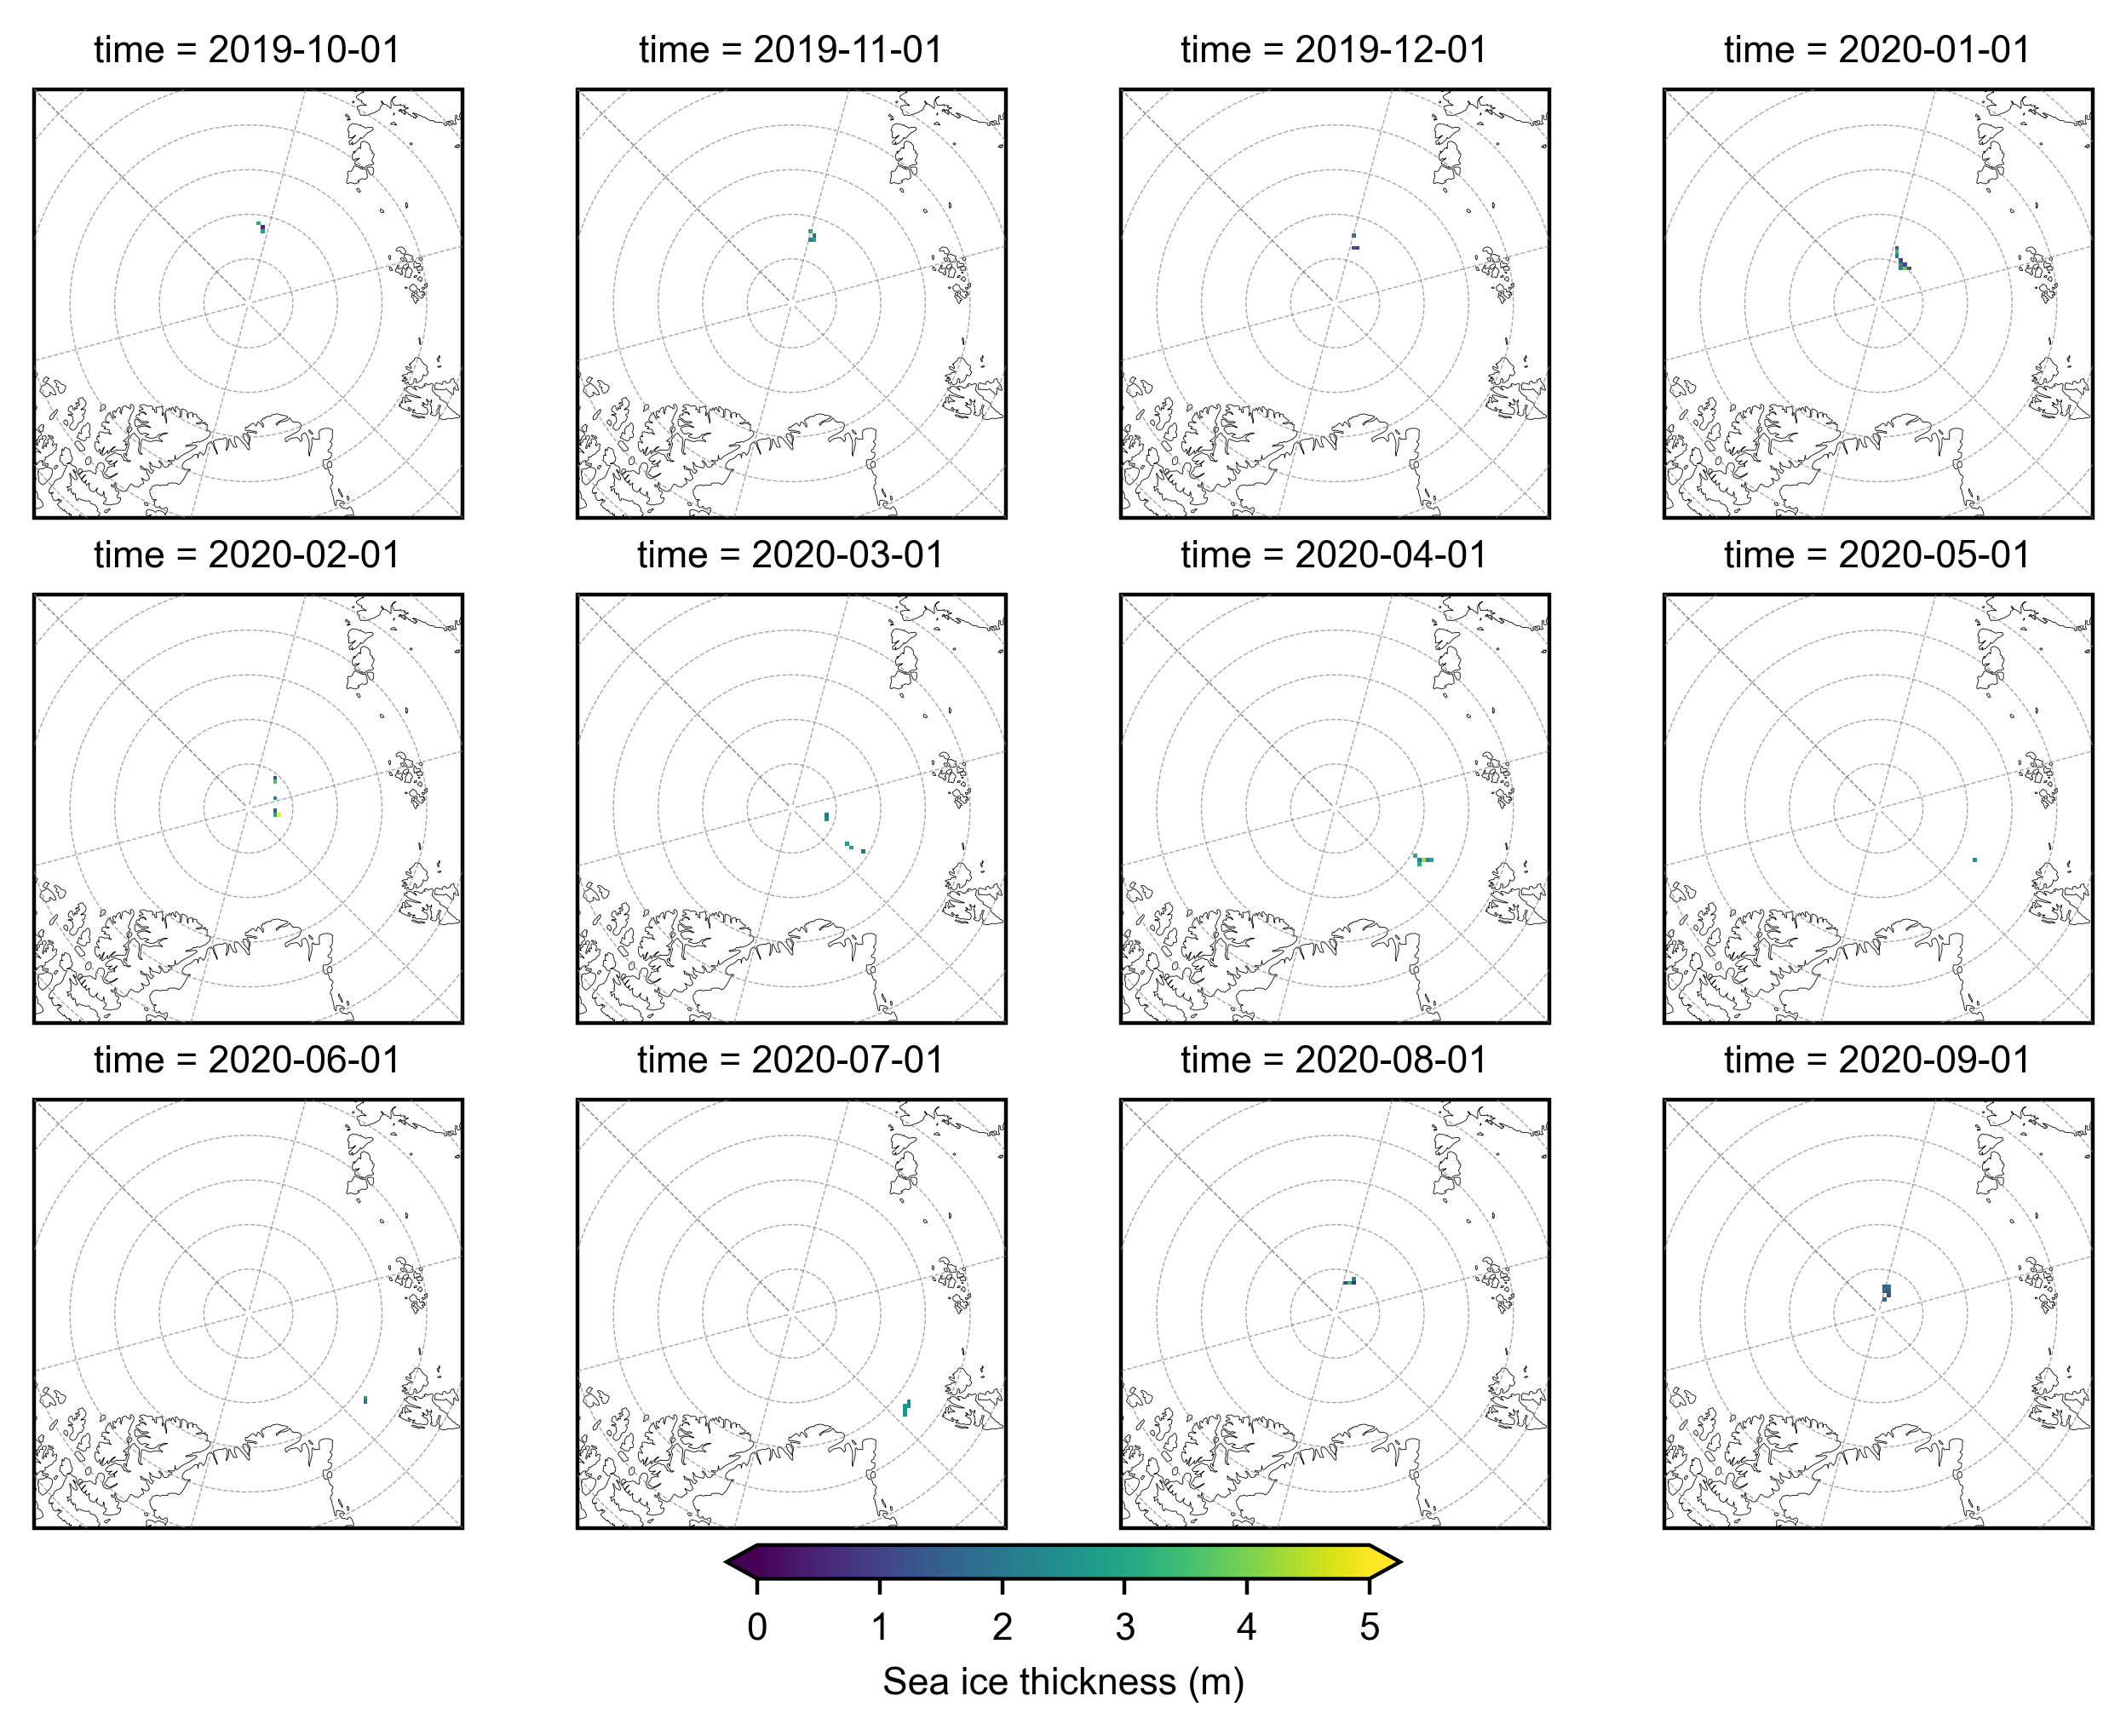

In [62]:

fig_width=6.8
fig_height=5.4

im1 = dataset_months.sea_ice_thickness_mean.plot(x="lon", y="lat", col='time', transform=ccrs.PlateCarree(), 
                       cmap="viridis", zorder=3, add_labels=False, col_wrap=4,
                       subplot_kws={'projection':ccrs.NorthPolarStereo(central_longitude=-45)},
                       cbar_kwargs={'pad':0.01,'shrink': 0.3,'extend':'both', 
                                  'label':'Sea ice thickness (m)', 'location':'bottom'},
                       vmin=0, vmax=5,
                       figsize=(fig_width, fig_height))


# Add map features to all subplots
i=0
for i, ax in enumerate(im1.axes.flatten()):
    ax.coastlines(linewidth=0.15, color='black', zorder=2)
    #ax.add_feature(cfeature.LAND, color='0.95', zorder=1)
    ax.gridlines(draw_labels=False, linewidth=0.25, color='gray', alpha=0.7, linestyle='--', zorder=3)
    ax.set_extent([-179, 179, 78, 90], crs=ccrs.PlateCarree())
    #ax.text(0.02, 0.93, panel_letters[i], transform=ax.transAxes, fontsize=7, va='bottom', ha='left')
    #ax.set_title('', fontsize=8)
    i+=1

#plt.subplots_adjust(wspace=0.01) 
#plt.savefig('./figs/maps_summer_thickness_comparison.png', dpi=300, facecolor="white")
plt.show()
plt.close()

In [71]:
For the snow_depth_sm, ice_thickness_sm, cs2_sea_ice_thickness_UBRIS variables in the IS2SITMOGR4_v3 dataset, make a new variable in the IS2SITMOGR4_v3 dataset which limits the time range to October through April and add a '_apr' label to the variable

<xarray.Dataset>
Dimensions:                         (time: 12, x: 304, y: 448)
Coordinates:
  * time                            (time) datetime64[ns] 2019-10-01 ... 2020...
  * x                               (x) float32 -3.838e+06 ... 3.738e+06
  * y                               (y) float32 5.838e+06 ... -5.338e+06
    longitude                       (y, x) float32 168.3 168.1 ... -10.18 -9.999
    latitude                        (y, x) float32 31.1 31.2 ... 34.58 34.47
Data variables: (12/38)
    crs                             (time) float64 dask.array<chunksize=(12,), meta=np.ndarray>
    ice_thickness_sm                (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_thickness_unc               (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    num_segments                    (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    mean_day_of_month               (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_depth_sm                   (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ...                              ...
    snow_density_w99                (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_depth                      (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_depth_int                  (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_depth_mw99                 (time, y, x) float32 dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    cs2_sea_ice_thickness_UBRIS     (time, y, x) float64 0.0 0.0 0.0 ... 0.0 0.0
    cs2_sea_ice_type_UBRIS          (time, y, x) float64 nan nan nan ... nan nan
Attributes:
    contact:      Alek Petty (akpetty@umd.edu)
    description:  Aggregated IS2SITMOGR4 summer V0 dataset.
    history:      Created 20/12/23

In [63]:


times = dataset_months.time.values
# Define a reference date (adjust as needed)
reference_date = np.datetime64('2019-09-15')
# Convert times to days since reference date
days_since_reference = (times - reference_date).astype('timedelta64[D]').astype(int)

shape = (len(times), dataset_months.sea_ice_thickness_mean.y.shape[0], dataset_months.sea_ice_thickness_mean.x.shape[0]) 
month_time = np.empty(shape)
month_time.fill(np.nan)

for i in range(len(times)):
    valid_cells = ~np.isnan(dataset_months['sea_ice_thickness_mean']).isel(time=i).values
    month_time[i][valid_cells] = days_since_reference[i]
mean_time = np.nanmean(month_time, axis=0)
mean_time


array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])

In [64]:

reference_date = np.datetime64('2019-09-15')  # Example reference date

# Initialize a dictionary to store validation results
validation_results = {}

# Calculate statistics and generate scatter plots for each variable
for var in variables_ice:
    # Calculate statistics
    IS2_var = IS2SITMOGR4_v3[var]
    IB_var = dataset_months['sea_ice_thickness_mean']
    IB_time = dataset_months['time']
    # Initialize lists to store the stacked points
    IB_comps_list = []
    IS2_comps_list = []
    IB_time_list = []
    # Loop through the time dimension
    for t in range(IS2_var.sizes['time']):
        IS2_var_time = IS2_var.isel(time=t)
        IB_var_time = IB_var.isel(time=t)
        print('IB time', IB_time.isel(time=t).values)
        valid_mask = ~np.isnan(IS2_var_time.values) & ~np.isnan(IB_var_time.values)
        IB_comps_list.append(IB_var_time.where(valid_mask).values.flatten()[~np.isnan(IB_var_time.where(valid_mask).values.flatten())])
        IS2_comps_list.append(IS2_var_time.where(valid_mask).values.flatten()[~np.isnan(IS2_var_time.where(valid_mask).values.flatten())])

        days_since_array = (IB_time.isel(time=t).values - reference_date).astype('timedelta64[D]').astype(int)
        print(days_since_array)

        IB_time_list.append([days_since_array]*len(IB_var_time.where(valid_mask).values.flatten()[~np.isnan(IB_var_time.where(valid_mask).values.flatten())]))
    # Stack the points together
    IB_comps = np.concatenate(IB_comps_list)
    IS2_comps = np.concatenate(IS2_comps_list)
    IB_time = np.concatenate(IB_time_list)
    # Correlation Coeff
    correlation = '%.02f' % (np.corrcoef(IS2_comps, IB_comps)[0, 1])
    # Calculate mean bias
    mean_bias = '%.02f' % (np.mean(IS2_comps - IB_comps))
    # Calculate standard dev of differences
    std_dev = '%.02f' % (np.std(IS2_comps - IB_comps))
    # Calculate RMSE    
    rmse = '%.02f' % (np.sqrt(np.mean((IS2_comps - IB_comps) ** 2)))
    
    # Store results
    validation_results[var] = {
        'r_str': correlation, 'mb_str': mean_bias, 'sd_str': std_dev, 'rmse': rmse, 
        'IB_comps': IB_comps, 'IS2_comps': IS2_comps,'IB_time': IB_time
    }

# Print validation results
print(validation_results)

IB time 2019-10-01T00:00:00.000000000
16
IB time 2019-11-01T00:00:00.000000000
47
IB time 2019-12-01T00:00:00.000000000
77
IB time 2020-01-01T00:00:00.000000000
108
IB time 2020-02-01T00:00:00.000000000
139
IB time 2020-03-01T00:00:00.000000000
168
IB time 2020-04-01T00:00:00.000000000
199
IB time 2020-05-01T00:00:00.000000000
229
IB time 2020-06-01T00:00:00.000000000
260
IB time 2020-07-01T00:00:00.000000000
290
IB time 2020-08-01T00:00:00.000000000
321
IB time 2020-09-01T00:00:00.000000000
352
IB time 2019-10-01T00:00:00.000000000
16
IB time 2019-11-01T00:00:00.000000000
47
IB time 2019-12-01T00:00:00.000000000
77
IB time 2020-01-01T00:00:00.000000000
108
IB time 2020-02-01T00:00:00.000000000
139
IB time 2020-03-01T00:00:00.000000000
168
IB time 2020-04-01T00:00:00.000000000
199
IB time 2020-05-01T00:00:00.000000000
229
IB time 2020-06-01T00:00:00.000000000
260
IB time 2020-07-01T00:00:00.000000000
290
IB time 2020-08-01T00:00:00.000000000
321
IB time 2020-09-01T00:00:00.000000000
35

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


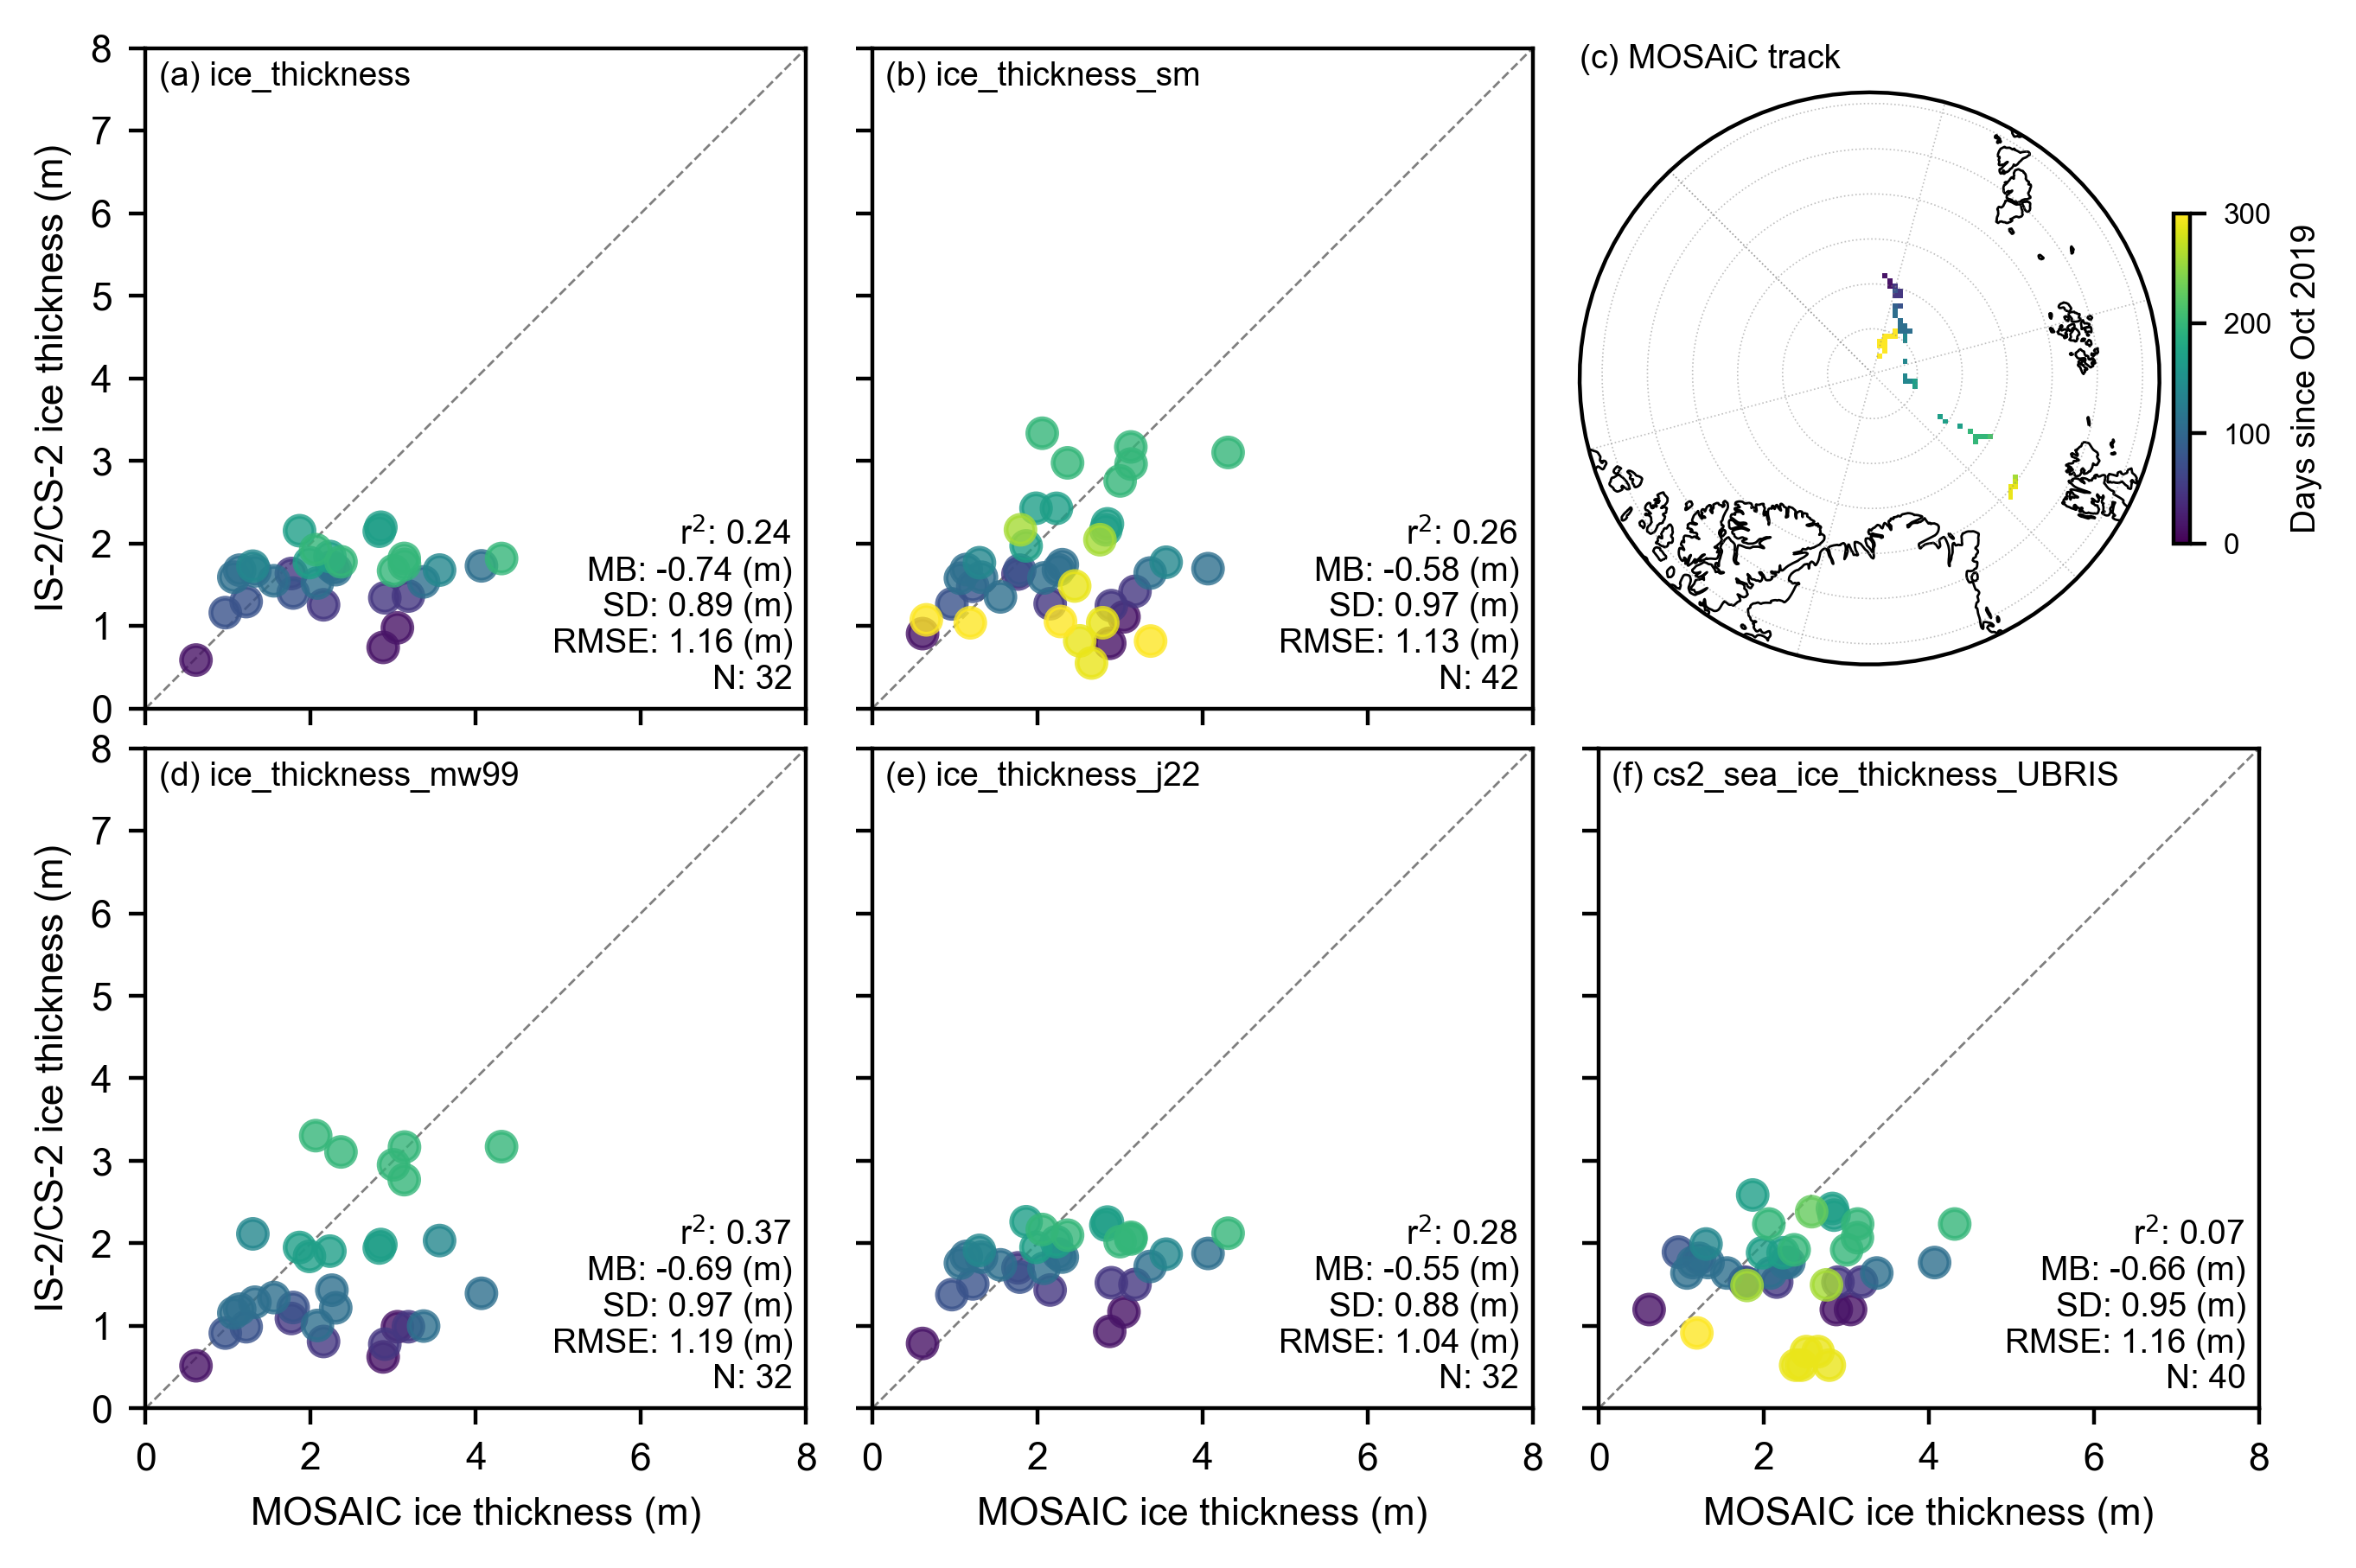

In [65]:


mpl.rcParams.update({
    "text.usetex": False,  # Use LaTeX for rendering
    "font.family": "serif",
    "font.size": 7,  # Match typical LaTeX 10pt font
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8
})

# Validation plot with subplots for each option
plt.rc('font', **{'family': 'sans-serif', 'sans-serif': ['Arial']})

# Create figure with subplots
fig = plt.figure(figsize=(6.8, 6.8*0.65))
gs = fig.add_gridspec(2, 3, hspace=0.06, wspace=0.04)

axes = []
for i in range(2):
    for j in range(3):
        if i == 0 and j == 2:
            # Create the cartopy map in the third position
            ax = fig.add_subplot(gs[i, j], projection=ccrs.NorthPolarStereo(central_longitude=-45))
        else:
            ax = fig.add_subplot(gs[i, j])
        axes.append(ax)

panel_labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']  # Panel labels

# Configure the cartopy map in the third subplot
map_ax = axes[2]
map_ax.set_extent([-180, 180, 77, 90], crs=ccrs.PlateCarree())
map_ax.coastlines(resolution='50m', color='black', linewidth=0.5)
map_ax.gridlines(draw_labels=False, linewidth=0.3, color='gray', alpha=0.5, linestyle=':')

# Add a circular boundary for the polar plot
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpl.path.Path(verts * radius + center)
map_ax.set_boundary(circle, transform=map_ax.transAxes)


# Plot the sea ice thickness data
im = map_ax.pcolormesh(
    dataset_months.x, 
    dataset_months.y, 
    mean_time, 
    transform=ccrs.NorthPolarStereo(central_longitude=-45),
    vmin=0,
    vmax=300,
    cmap='viridis',
)

# Add colorbar with reduced size
cbar = plt.colorbar(im, ax=map_ax, orientation='vertical', pad=0.02, shrink=0.5)
cbar.set_label('Days since Oct 2019', fontsize=7)
cbar.ax.tick_params(labelsize=6)

# Add panel label
map_ax.annotate(f"{panel_labels[2]} MOSAiC track", xy=(0.0, 1.03), 
                xycoords='axes fraction', 
                horizontalalignment='left', 
                verticalalignment='bottom',
                fontsize=7)

# Process the other subplots as before
for i, option in enumerate(variables_ice):
    if i < 2:
        ax_idx = i
    else:
        ax_idx = i + 1  # Skip the map subplot
    
    ax = axes[ax_idx]
    im = ax.scatter(validation_results[option]['IB_comps'], validation_results[option]['IS2_comps'], 
                   c=validation_results[option]['IB_time'], alpha=0.8, vmin=0, vmax=300)

    # Retrieve validation results for the current option
    r_str = validation_results[option]['r_str']
    mb_str = validation_results[option]['mb_str']
    sd_str = validation_results[option]['sd_str']
    n_str = str(len(validation_results[option]['IS2_comps']))

    # Calculate RMSE for each ULS
    rmse = validation_results[option]['rmse']

    # Annotate the plot with statistics
    ax.annotate(f"r$^2$: {r_str} \nMB: {mb_str} (m)\nSD: {sd_str} (m)\nRMSE: {rmse} (m)\nN: {n_str}", 
                color='k', xy=(0.98, 0.02), xycoords='axes fraction', 
                horizontalalignment='right', verticalalignment='bottom', fontsize=7)

    # Combine panel label with option label
    ax.annotate(f"{panel_labels[ax_idx]} "+option, xy=(0.02, 0.98), 
                xycoords='axes fraction', horizontalalignment='left', verticalalignment='top')

    # Set x and y labels only for the leftmost and bottom plots
    if (ax_idx == 0):
        ax.legend(frameon=False, loc="upper right")
    if (ax_idx == 0) or (ax_idx == 3):
        ax.set_ylabel('IS-2/CS-2 ice thickness (m)')
    else:
        ax.set_yticklabels('')
    if ax_idx >= 3:
        ax.set_xlabel('MOSAIC ice thickness (m)')
    else:
        ax.set_xlabel('')
        ax.set_xticklabels('')

    ax.set_xlim([0, 8])
    ax.set_ylim([0, 8])
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
        np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
    ]
    ax.plot(lims, lims, 'k--', linewidth=0.5, alpha=0.5, zorder=0)
    ax.set_aspect('equal')
    ax.set_xlim(lims)
    ax.set_ylim(lims)

plt.subplots_adjust(left=0.065, right=0.98, top=0.98, bottom=0.09)  # Adjust these values to reduce whitespace

plt.savefig('./figs/MOSAIC_scatter_inccs2_'+ib_agg_str+'_'+str(grid_size)+'km_map'+extra+'.pdf', dpi=300)
plt.show()

In [66]:
dataset_months

<xarray.Dataset>
Dimensions:                   (y: 448, x: 304, time: 12)
Coordinates:
    lon                       (y, x) float32 168.3 168.1 168.0 ... -10.18 -9.999
    lat                       (y, x) float32 31.1 31.2 31.3 ... 34.58 34.47
    crs                       int64 0
  * x                         (x) float32 -3.838e+06 -3.812e+06 ... 3.738e+06
  * y                         (y) float32 5.838e+06 5.812e+06 ... -5.338e+06
  * time                      (time) datetime64[ns] 2019-10-01 ... 2020-09-01
Data variables:
    snow_thickness_mean       (time, y, x) float32 nan nan nan ... nan nan nan
    snow_thickness_median     (time, y, x) float32 nan nan nan ... nan nan nan
    snow_thickness_count      (time, y, x) float32 nan nan nan ... nan nan nan
    sea_ice_thickness_mean    (time, y, x) float32 nan nan nan ... nan nan nan
    sea_ice_thickness_median  (time, y, x) float32 nan nan nan ... nan nan nan
    sea_ice_thickness_count   (time, y, x) float32 nan nan nan ... nan nan nan

In [67]:


# Initialize a dictionary to store validation results
validation_results_snow = {}

# Calculate statistics and generate scatter plots for each variable
for var in variables_snow:
    # Calculate statistics
    IS2_var = IS2SITMOGR4_v3[var]
    IB_var = dataset_months['snow_thickness_mean']
    IB_time = dataset_months['time']
    # Initialize lists to store the stacked points
    IB_comps_list = []
    IS2_comps_list = []
    IB_time_list = []
    # Loop through the time dimension
    for t in range(IS2_var.sizes['time']):
        IS2_var_time = IS2_var.isel(time=t)
        IB_var_time = IB_var.isel(time=t)
        
        valid_mask = ~np.isnan(IS2_var_time.values) & ~np.isnan(IB_var_time.values)
        IB_comps_list.append(IB_var_time.where(valid_mask).values.flatten()[~np.isnan(IB_var_time.where(valid_mask).values.flatten())])
        IS2_comps_list.append(IS2_var_time.where(valid_mask).values.flatten()[~np.isnan(IS2_var_time.where(valid_mask).values.flatten())])
        
        days_since_array = (IB_time.isel(time=t).values - reference_date).astype('timedelta64[D]').astype(int)
        print(days_since_array)

        IB_time_list.append([days_since_array]*len(IB_var_time.where(valid_mask).values.flatten()[~np.isnan(IB_var_time.where(valid_mask).values.flatten())]))
    
    # Stack the points together
    IB_comps = np.concatenate(IB_comps_list)
    IS2_comps = np.concatenate(IS2_comps_list)
    IB_time = np.concatenate(IB_time_list)
    # Correlation Coeff
    correlation = '%.02f' % (np.corrcoef(IS2_comps, IB_comps)[0, 1])
    # Calculate mean bias
    mean_bias = '%.02f' % (np.mean(IS2_comps - IB_comps))
    # Calculate standard dev of differences
    std_dev = '%.02f' % (np.std(IS2_comps - IB_comps))
    # Calculate RMSE    
    rmse = '%.02f' % (np.sqrt(np.mean((IS2_comps - IB_comps) ** 2)))
    
    # Store results
    validation_results_snow[var] = {
        'r_str': correlation, 'mb_str': mean_bias, 'sd_str': std_dev, 'rmse': rmse, 'IB_comps': IB_comps, 'IS2_comps': IS2_comps, 'IB_time': IB_time
    }

# Print validation results
print(validation_results_snow)

16
47
77
108
139
168
199
229
260
290
321
352
16
47
77
108
139
168
199
229
260
290
321
352
16
47
77
108
139
168
199
229
260
290
321
352
{'snow_depth': {'r_str': '0.73', 'mb_str': '-0.01', 'sd_str': '0.05', 'rmse': '0.06', 'IB_comps': array([0.19315174, 0.11506602, 0.21909037, 0.22141254, 0.17134511,
       0.17287391, 0.20862977, 0.21994378, 0.20235905, 0.14986773,
       0.20344783, 0.24765149, 0.24085438, 0.11071029, 0.19044071,
       0.1235292 , 0.2231086 , 0.25789344, 0.15987109, 0.15824062,
       0.32622883, 0.30666384, 0.2504738 , 0.2764157 , 0.25050858,
       0.25115484, 0.2841268 , 0.3101109 , 0.45233086, 0.29145402,
       0.30214265, 0.29932392], dtype=float32), 'IS2_comps': array([0.142, 0.135, 0.138, 0.134, 0.132, 0.136, 0.135, 0.185, 0.182,
       0.174, 0.192, 0.188, 0.182, 0.184, 0.19 , 0.19 , 0.189, 0.189,
       0.192, 0.236, 0.228, 0.257, 0.262, 0.24 , 0.235, 0.264, 0.331,
       0.358, 0.367, 0.369, 0.368, 0.372], dtype=float32), 'IB_time': array([ 16.,  16.,  16.,

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


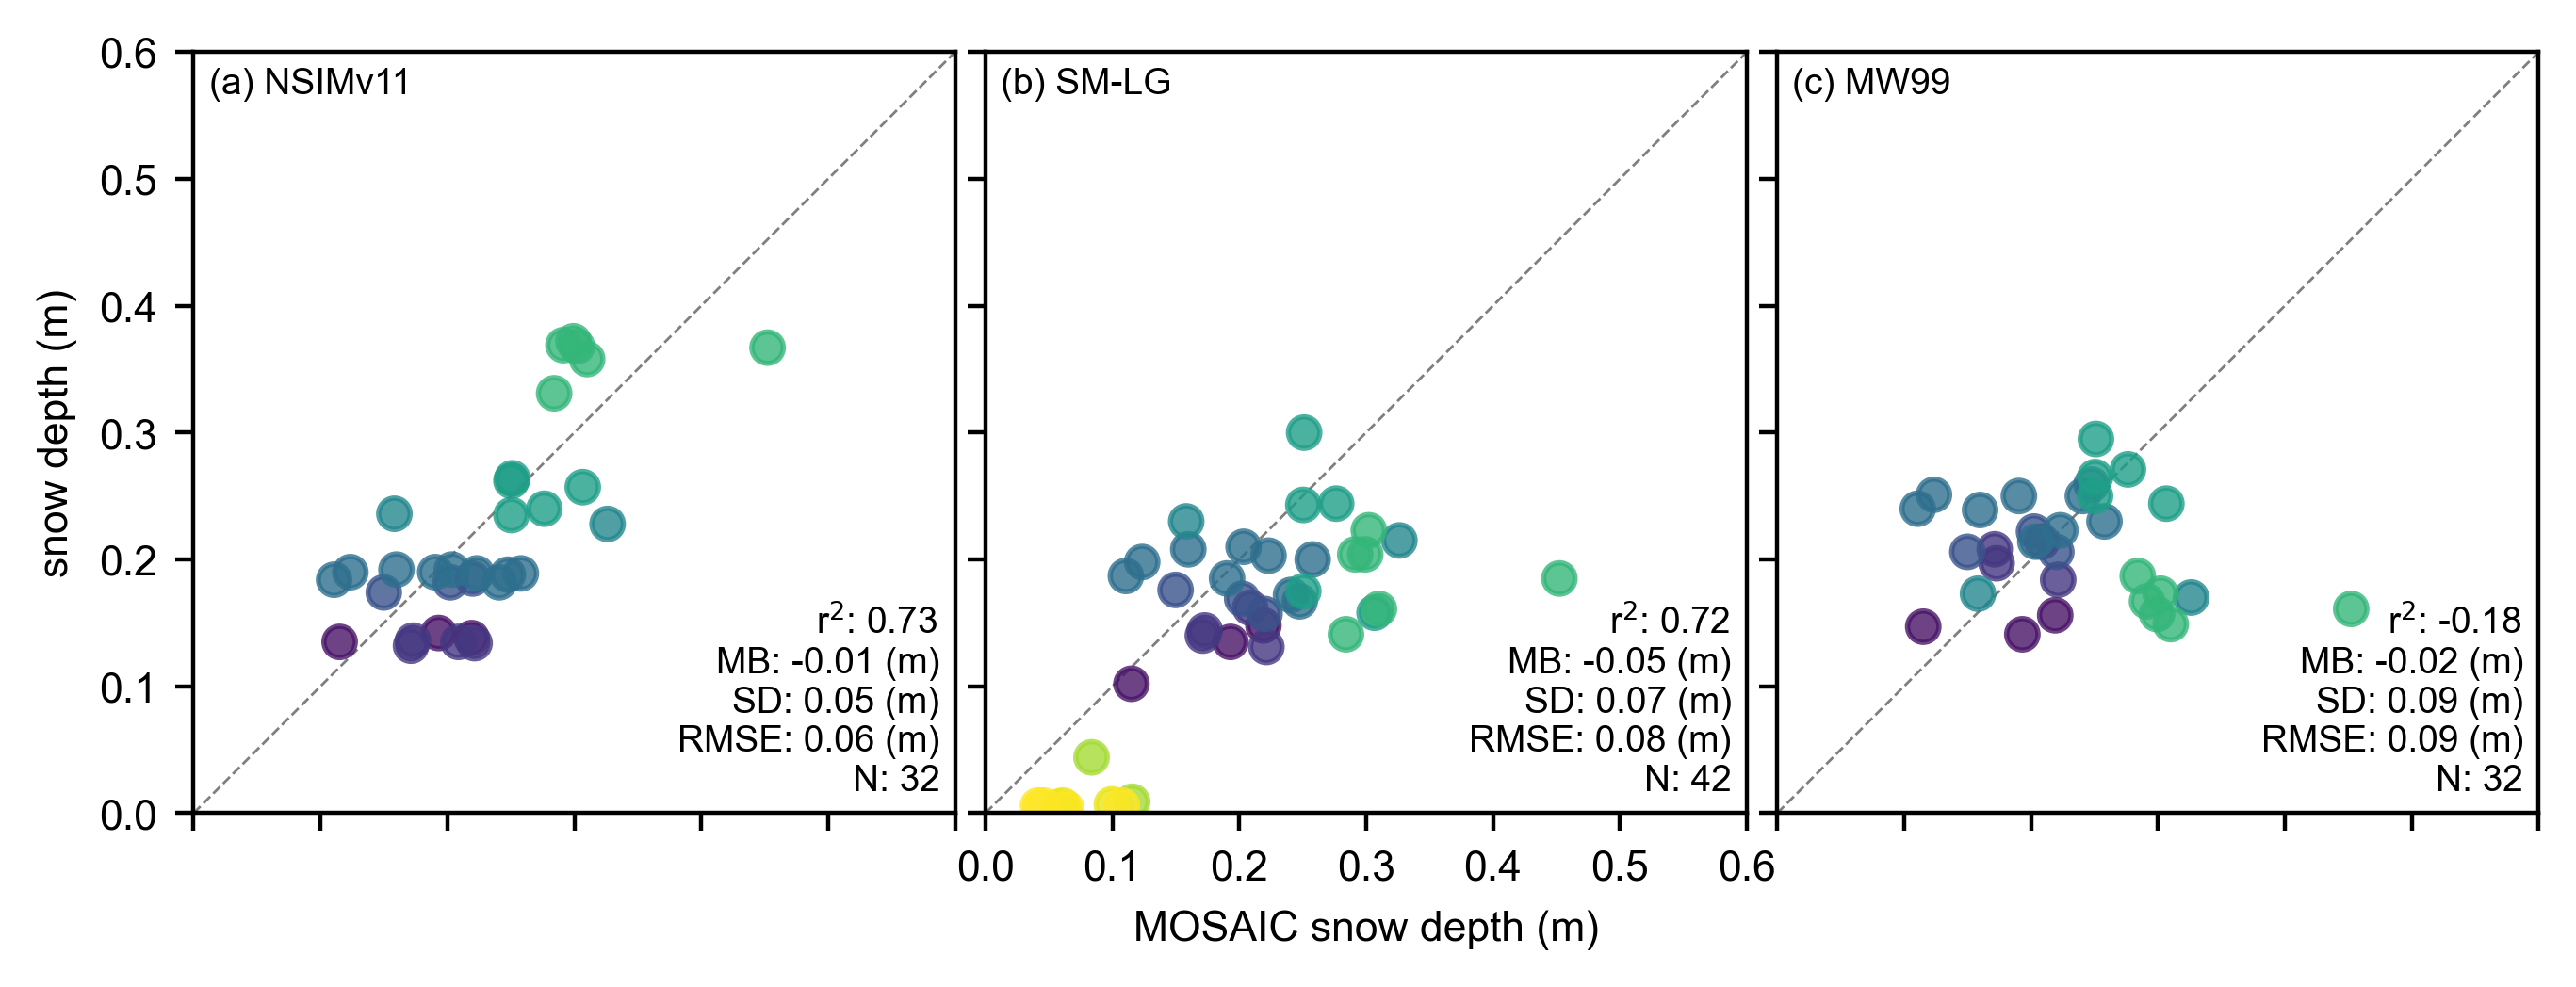

In [68]:


mpl.rcParams.update({
    "text.usetex": False,  # Use LaTeX for rendering
    "font.family": "serif",
    "font.size": 7,  # Match typical LaTeX 10pt font
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8
})

snow_labels=['NSIMv11', 'SM-LG', 'MW99']
# Validation plot with subplots for each option
plt.rc('font', **{'family': 'sans-serif', 'sans-serif': ['Arial']})

fig, axes = plt.subplots(1, 3, figsize=(6.8, 6.8*0.36), gridspec_kw={'hspace': 0.06, 'wspace': 0.04})  # Adjust hspace and wspace for less whitespace
axes = axes.flatten()  # Flatten the 2D array of axes for easy iteration
panel_labels = ['(a)', '(b)', '(c)']  # Panel labels


for i, option in enumerate(variables_snow):
    ax = axes[i]

    ax.scatter(validation_results_snow[option]['IB_comps'], validation_results_snow[option]['IS2_comps'], c=validation_results_snow[option]['IB_time'], alpha=0.8, vmin=0, vmax=300)

    # Retrieve validation results for the current option
    r_str= validation_results_snow[option]['r_str']
    mb_str = validation_results_snow[option]['mb_str']
    sd_str = validation_results_snow[option]['sd_str']
    n_str =  str(len(validation_results_snow[option]['IS2_comps']))

    # Calculate RMSE for each ULS
    rmse = validation_results_snow[option]['rmse']

    # Annotate the plot with RMSE, mean bias, and standard deviation
    #ax.annotate(f"A  r$^2$: {r_str_a}  MB: {mb_str_a} (m) SD: {sd_str_a} (m)  RMSE: {rmse_a:.02f} (m)", color='b', xy=(0.02, 0.98), xycoords='axes fraction', horizontalalignment='left', verticalalignment='top', fontsize=9)
    #ax.annotate(f"B  r$^2$: {r_str_b}  MB: {mb_str_b} (m) SD: {sd_str_b} (m)  RMSE: {rmse_b:.02f} (m)", color='tab:red', xy=(0.02, 0.92), xycoords='axes fraction', horizontalalignment='left', verticalalignment='top', fontsize=9)
    #ax.annotate(f"D  r$^2$: {r_str_d}  MB: {mb_str_d} (m) SD: {sd_str_d} (m)  RMSE: {rmse_d:.02f} (m)", color='tab:orange', xy=(0.02, 0.86), xycoords='axes fraction', horizontalalignment='left', verticalalignment='top', fontsize=9)
    ax.annotate(f"r$^2$: {r_str} \nMB: {mb_str} (m)\nSD: {sd_str} (m)\nRMSE: {rmse} (m)\nN: {n_str}", color='k', xy=(0.98, 0.02), xycoords='axes fraction', horizontalalignment='right', verticalalignment='bottom', fontsize=7)

    # Combine panel label with option label
    ax.annotate(f"{panel_labels[i]} "+snow_labels[i], xy=(0.02, 0.98), xycoords='axes fraction', horizontalalignment='left', verticalalignment='top')

    # Set x and y labels only for the leftmost and bottom plots
    if (i==0):
        ax.legend(frameon=False, loc="upper right")
    if (i == 0):
        ax.set_ylabel('snow depth (m)')
    else:
        ax.set_yticklabels('')
    if i == 1:
        ax.set_xlabel('MOSAIC snow depth (m)')
    else:
        ax.set_xlabel('')
        ax.set_xticklabels('')

    ax.set_xlim([0, 0.6])
    ax.set_ylim([0, 0.6])
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
        np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
    ]
    ax.plot(lims, lims, 'k--', linewidth=0.5, alpha=0.5, zorder=0)
    ax.set_aspect('equal')
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    #ax.legend()

#plt.tight_layout()
plt.subplots_adjust(left=0.065, right=0.98, top=0.98, bottom=0.15)  # Adjust these values to reduce whitespace

plt.savefig('./figs/MOSAIC_scatter_snow_inccs2_'+ib_agg_str+'_'+str(grid_size)+'km'+extra+'.pdf', dpi=300)
plt.show()

# ... existing code ...

In [69]:
validation_results_snow

{'snow_depth': {'r_str': '0.73',
  'mb_str': '-0.01',
  'sd_str': '0.05',
  'rmse': '0.06',
  'IB_comps': array([0.19315174, 0.11506602, 0.21909037, 0.22141254, 0.17134511,
         0.17287391, 0.20862977, 0.21994378, 0.20235905, 0.14986773,
         0.20344783, 0.24765149, 0.24085438, 0.11071029, 0.19044071,
         0.1235292 , 0.2231086 , 0.25789344, 0.15987109, 0.15824062,
         0.32622883, 0.30666384, 0.2504738 , 0.2764157 , 0.25050858,
         0.25115484, 0.2841268 , 0.3101109 , 0.45233086, 0.29145402,
         0.30214265, 0.29932392], dtype=float32),
  'IS2_comps': array([0.142, 0.135, 0.138, 0.134, 0.132, 0.136, 0.135, 0.185, 0.182,
         0.174, 0.192, 0.188, 0.182, 0.184, 0.19 , 0.19 , 0.189, 0.189,
         0.192, 0.236, 0.228, 0.257, 0.262, 0.24 , 0.235, 0.264, 0.331,
         0.358, 0.367, 0.369, 0.368, 0.372], dtype=float32),
  'IB_time': array([ 16.,  16.,  16.,  47.,  47.,  47.,  47.,  77.,  77.,  77., 108.,
         108., 108., 108., 108., 108., 108., 108., 108.,

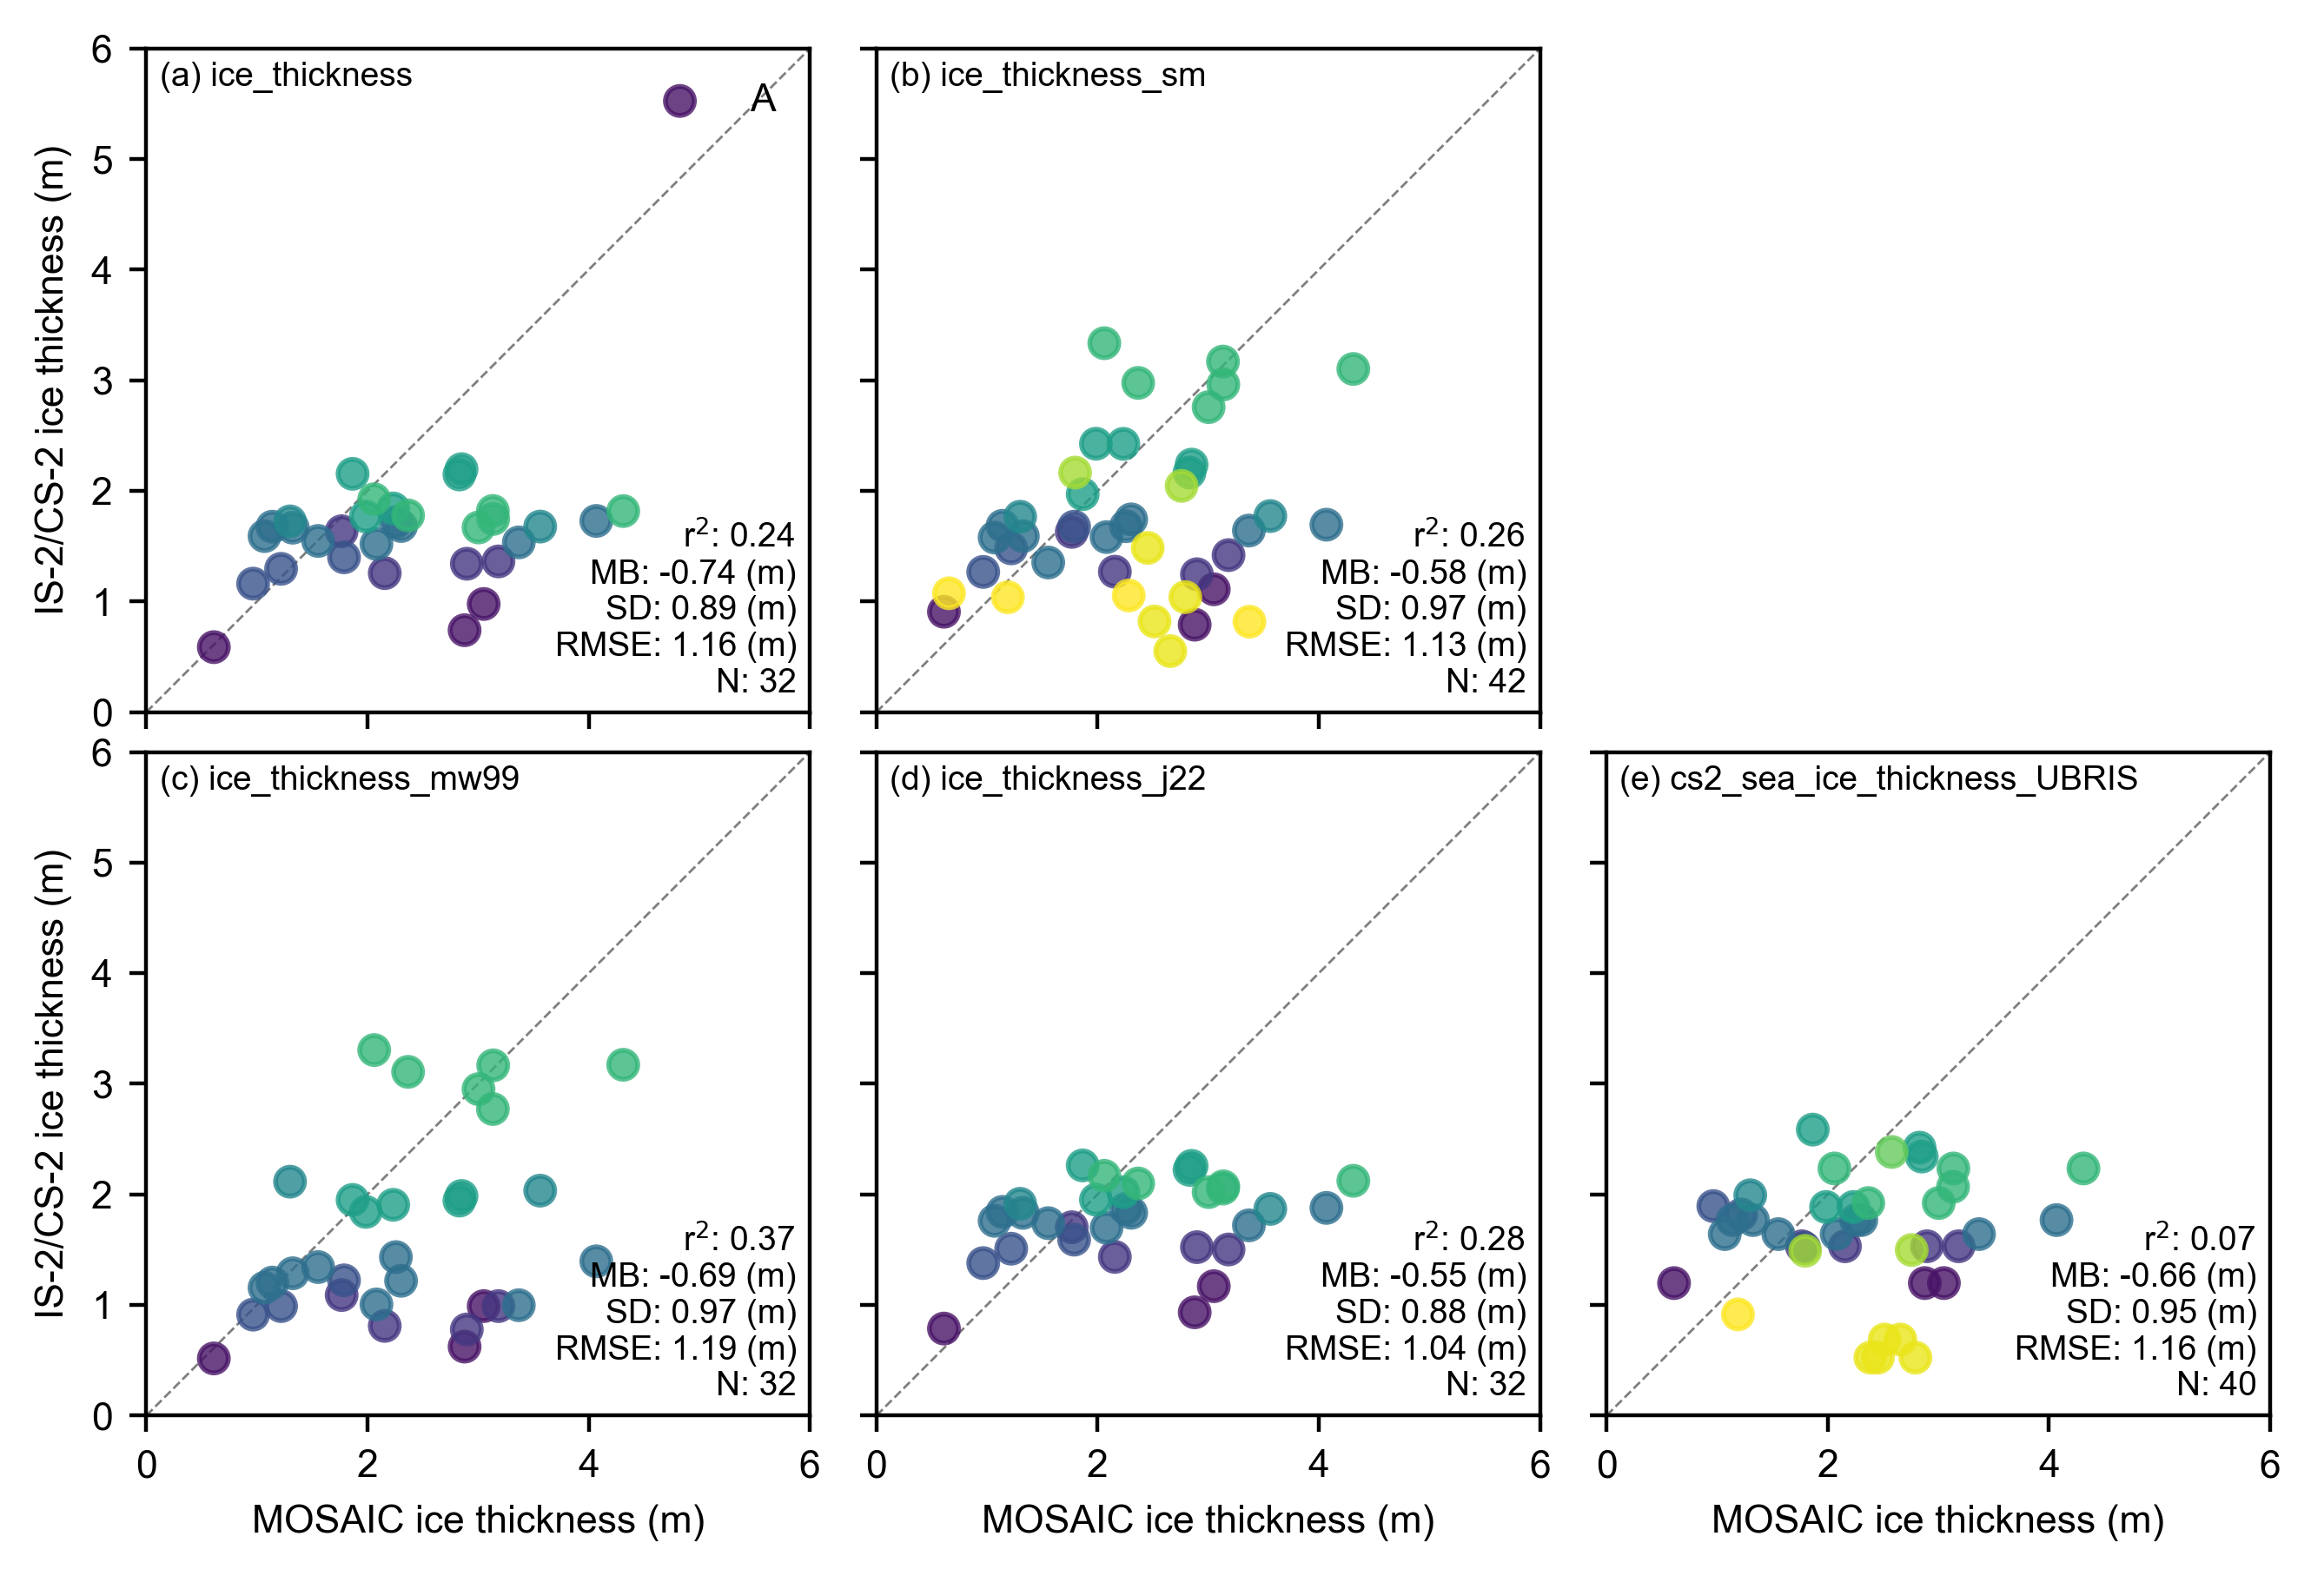

In [70]:
# OLD WAY WITHOUT MAP
# 


mpl.rcParams.update({
    "text.usetex": False,  # Use LaTeX for rendering
    "font.family": "serif",
    "font.size": 7,  # Match typical LaTeX 10pt font
    "axes.labelsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8
})

# Validation plot with subplots for each option
plt.rc('font', **{'family': 'sans-serif', 'sans-serif': ['Arial']})

fig, axes = plt.subplots(2, 3, figsize=(6.8, 6.8*0.65), gridspec_kw={'hspace': 0.06, 'wspace': 0.04})  # Adjust hspace and wspace for less whitespace
axes = axes.flatten()  # Flatten the 2D array of axes for easy iteration
panel_labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']  # Panel labels

# Leave the third subplot on the top row empty
axes[2].axis('off')

for i, option in enumerate(variables_ice):
    ax = axes[i if i < 2 else i + 1]  # Skip the third subplot on the top row
    #ax = axes[i]  # Skip the third subplot on the top row
    ax.scatter(validation_results[option]['IB_comps'], validation_results[option]['IS2_comps'], c=validation_results[option]['IB_time'], alpha=0.8, vmin=0, vmax=300, label='A')

    # Retrieve validation results for the current option
    r_str= validation_results[option]['r_str']
    mb_str = validation_results[option]['mb_str']
    sd_str = validation_results[option]['sd_str']
    n_str =  str(len(validation_results[option]['IS2_comps']))

    # Calculate RMSE for each ULS
    rmse = validation_results[option]['rmse']

    # Annotate the plot with RMSE, mean bias, and standard deviation
    #ax.annotate(f"A  r$^2$: {r_str_a}  MB: {mb_str_a} (m) SD: {sd_str_a} (m)  RMSE: {rmse_a:.02f} (m)", color='b', xy=(0.02, 0.98), xycoords='axes fraction', horizontalalignment='left', verticalalignment='top', fontsize=9)
    #ax.annotate(f"B  r$^2$: {r_str_b}  MB: {mb_str_b} (m) SD: {sd_str_b} (m)  RMSE: {rmse_b:.02f} (m)", color='tab:red', xy=(0.02, 0.92), xycoords='axes fraction', horizontalalignment='left', verticalalignment='top', fontsize=9)
    #ax.annotate(f"D  r$^2$: {r_str_d}  MB: {mb_str_d} (m) SD: {sd_str_d} (m)  RMSE: {rmse_d:.02f} (m)", color='tab:orange', xy=(0.02, 0.86), xycoords='axes fraction', horizontalalignment='left', verticalalignment='top', fontsize=9)
    ax.annotate(f"r$^2$: {r_str} \nMB: {mb_str} (m)\nSD: {sd_str} (m)\nRMSE: {rmse} (m)\nN: {n_str}", color='k', xy=(0.98, 0.02), xycoords='axes fraction', horizontalalignment='right', verticalalignment='bottom', fontsize=7)

    # Combine panel label with option label
    ax.annotate(f"{panel_labels[i]} "+option, xy=(0.02, 0.98), xycoords='axes fraction', horizontalalignment='left', verticalalignment='top')

    # Set x and y labels only for the leftmost and bottom plots
    if (i==0):
        ax.legend(frameon=False, loc="upper right")
    if (i == 0)|(i==2):
        ax.set_ylabel('IS-2/CS-2 ice thickness (m)')
    else:
        ax.set_yticklabels('')
    if i >= 2:
        ax.set_xlabel('MOSAIC ice thickness (m)')
    else:
        ax.set_xlabel('')
        ax.set_xticklabels('')

    ax.set_xlim([0, 6])
    ax.set_ylim([0, 6])
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
        np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
    ]
    ax.plot(lims, lims, 'k--', linewidth=0.5, alpha=0.5, zorder=0)
    ax.set_aspect('equal')
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    #ax.legend()

#plt.tight_layout()
plt.subplots_adjust(left=0.065, right=0.98, top=0.98, bottom=0.09)  # Adjust these values to reduce whitespace

#plt.savefig('./figs/MOSAIC_scatter_inccs2_'+ib_agg_str+'_'+str(grid_size)+'km_nomap.pdf', dpi=300)
plt.show()

# ... existing code ...